In [2]:
# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

In [3]:
# 2. Load dataset (upload the CSV to Colab first, or mount Drive)
from google.colab import files
uploaded = files.upload()   # choose student_placement_salary_elite_v2.csv

df = pd.read_csv('student_placement_salary_elite_v2.csv')

Saving student_placement_salary_elite_v2.csv to student_placement_salary_elite_v2.csv


In [ ]:
print("Shape:", df.shape)
df.head()

Shape: (9000, 20)


,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,MNC,Software Engineer,63.55
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,MNC,Data Scientist,75.17
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,MNC,Software Engineer,80.44
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,83.6,0,6,0,74.3,2,1,MNC,Software Engineer,72.11
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,86.3,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05


In [4]:
df.info()
df.describe(include='all').T
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           9000 non-null   object 
 1   cgpa                 9000 non-null   float64
 2   branch               9000 non-null   object 
 3   college_tier         9000 non-null   int64  
 4   python_skill         9000 non-null   int64  
 5   dsa_skill            9000 non-null   int64  
 6   ml_skill             9000 non-null   int64  
 7   web_dev_skill        9000 non-null   int64  
 8   coding_score         9000 non-null   float64
 9   communication_score  9000 non-null   float64
 10  aptitude_score       9000 non-null   float64
 11  internships          9000 non-null   int64  
 12  projects             9000 non-null   int64  
 13  backlogs             9000 non-null   int64  
 14  resume_score         9000 non-null   float64
 15  skill_score          9000 non-null   i

Placement distribution:
placed
1    7702
0    1298
Name: count, dtype: int64

Placement rate: 85.58%


/tmp/ipykernel_30307/1073685890.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='placed', data=df, palette='Set2')


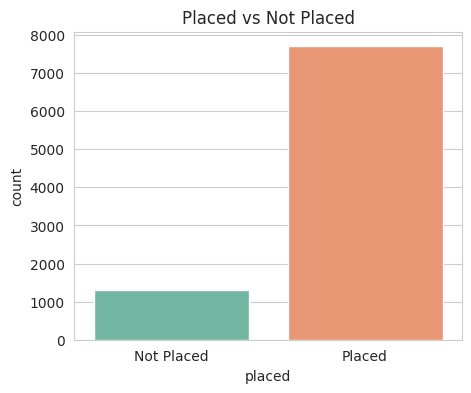

In [25]:
# Target 1: placed (classification)
print("Placement distribution:")
print(df['placed'].value_counts())
print("\nPlacement rate: {:.2f}%".format(df['placed'].mean() * 100))

plt.figure(figsize=(5,4))
sns.countplot(x='placed', data=df, palette='Set2')
plt.title('Placed vs Not Placed')
plt.xticks([0,1], ['Not Placed', 'Placed'])
plt.show()


Salary stats (placed students only):
count    7702.000000
mean       64.747312
std        17.035688
min        32.830000
25%        49.020000
50%        65.870000
75%        77.482500
max       129.430000
Name: salary_lpa, dtype: float64


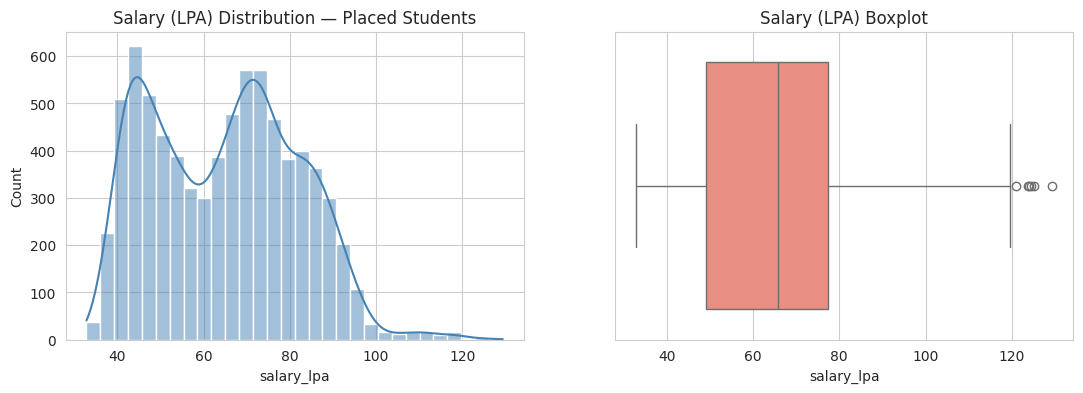

In [26]:
# Target 2: salary_lpa (regression) — only for placed students
placed_df = df[df['placed'] == 1]
print("\nSalary stats (placed students only):")
print(placed_df['salary_lpa'].describe())

fig, ax = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(placed_df['salary_lpa'], kde=True, bins=30, color='steelblue', ax=ax[0])
ax[0].set_title('Salary (LPA) Distribution — Placed Students')
sns.boxplot(x=placed_df['salary_lpa'], color='salmon', ax=ax[1])
ax[1].set_title('Salary (LPA) Boxplot')
plt.show()

**Key Takeaways**


*   Average and median are very close so distribution is roughly symmetric
*   There's significant variation in packages.
*   Top 25% of students are getting 77.5 LPA and above

**Histogram**
*   Many students getting mid-tier offers (likely from Mid-size companies or Startups).
*   The majority of good offers (likely from MNCs and Top Tech)
*   Very few students below 40 LPA or above 110 LPA

**Boxplot**
*   ~49 to ~77 LPA is where the middle 50% of placed students fall.
*   Median line is around 66 LPA.
*   There are several outliers on the higher end (above ~110-120 LPA) — these are likely the students who got into Top Tech / Dream Companies.
*   No major lower outliers.

In [27]:
# 5. Unique values in categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts(dropna=False))

Categorical columns: ['student_id', 'branch', 'company_type', 'job_role']

--- student_id (9000 unique) ---
student_id
S8999    1
S0       1
S1       1
S2       1
S3       1
        ..
S12      1
S11      1
S10      1
S9       1
S8       1
Name: count, Length: 9000, dtype: int64

--- branch (6 unique) ---
branch
IT            1564
Civil         1504
ECE           1499
CSE           1496
EEE           1478
Mechanical    1459
Name: count, dtype: int64

--- company_type (5 unique) ---
company_type
MNC           3179
Startup       2230
Mid-size      2158
Not Placed    1298
Top Tech       135
Name: count, dtype: int64

--- job_role (5 unique) ---
job_role
Web Developer        1939
Data Scientist       1938
Software Engineer    1937
Analyst              1888
Not Placed           1298
Name: count, dtype: int64


In [5]:
# Create a new feature
df['placed'] = df['placed'].astype(int)

# Fill NaN with meaningful values
df['company_type'] = df['company_type'].fillna('Not Placed')
df['job_role'] = df['job_role'].fillna('Not Placed')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           9000 non-null   object 
 1   cgpa                 9000 non-null   float64
 2   branch               9000 non-null   object 
 3   college_tier         9000 non-null   int64  
 4   python_skill         9000 non-null   int64  
 5   dsa_skill            9000 non-null   int64  
 6   ml_skill             9000 non-null   int64  
 7   web_dev_skill        9000 non-null   int64  
 8   coding_score         9000 non-null   float64
 9   communication_score  9000 non-null   float64
 10  aptitude_score       9000 non-null   float64
 11  internships          9000 non-null   int64  
 12  projects             9000 non-null   int64  
 13  backlogs             9000 non-null   int64  
 14  resume_score         9000 non-null   float64
 15  skill_score          9000 non-null   i

In [28]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts(dropna=False))

Categorical columns: ['student_id', 'branch', 'company_type', 'job_role']

--- student_id (9000 unique) ---
student_id
S8999    1
S0       1
S1       1
S2       1
S3       1
        ..
S12      1
S11      1
S10      1
S9       1
S8       1
Name: count, Length: 9000, dtype: int64

--- branch (6 unique) ---
branch
IT            1564
Civil         1504
ECE           1499
CSE           1496
EEE           1478
Mechanical    1459
Name: count, dtype: int64

--- company_type (5 unique) ---
company_type
MNC           3179
Startup       2230
Mid-size      2158
Not Placed    1298
Top Tech       135
Name: count, dtype: int64

--- job_role (5 unique) ---
job_role
Web Developer        1939
Data Scientist       1938
Software Engineer    1937
Analyst              1888
Not Placed           1298
Name: count, dtype: int64


In [29]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical columns:", numerical_cols)

for col in numerical_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts(dropna=False).sort_index())

Numerical columns: ['cgpa', 'college_tier', 'python_skill', 'dsa_skill', 'ml_skill', 'web_dev_skill', 'coding_score', 'communication_score', 'aptitude_score', 'internships', 'projects', 'backlogs', 'resume_score', 'skill_score', 'placed', 'salary_lpa']

--- cgpa (501 unique) ---
cgpa
5.00      4
5.01     20
5.02     18
5.03     18
5.04      5
         ..
9.96     17
9.97     14
9.98     26
9.99     15
10.00    12
Name: count, Length: 501, dtype: int64

--- college_tier (3 unique) ---
college_tier
1    2960
2    2974
3    3066
Name: count, dtype: int64

--- python_skill (2 unique) ---
python_skill
0    3149
1    5851
Name: count, dtype: int64

--- dsa_skill (2 unique) ---
dsa_skill
0    4000
1    5000
Name: count, dtype: int64

--- ml_skill (2 unique) ---
ml_skill
0    6302
1    2698
Name: count, dtype: int64

--- web_dev_skill (2 unique) ---
web_dev_skill
0    5459
1    3541
Name: count, dtype: int64

--- coding_score (1001 unique) ---
coding_score
0.0       6
0.1      11
0.2      11
0

# EDA

### Univariate Analysis — CGPA, Skills, Internships, Salary

/tmp/ipykernel_30307/1856158411.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='skill_score', data=df, ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_30307/1856158411.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='internships', data=df, ax=axes[1, 0], palette='YlOrBr')


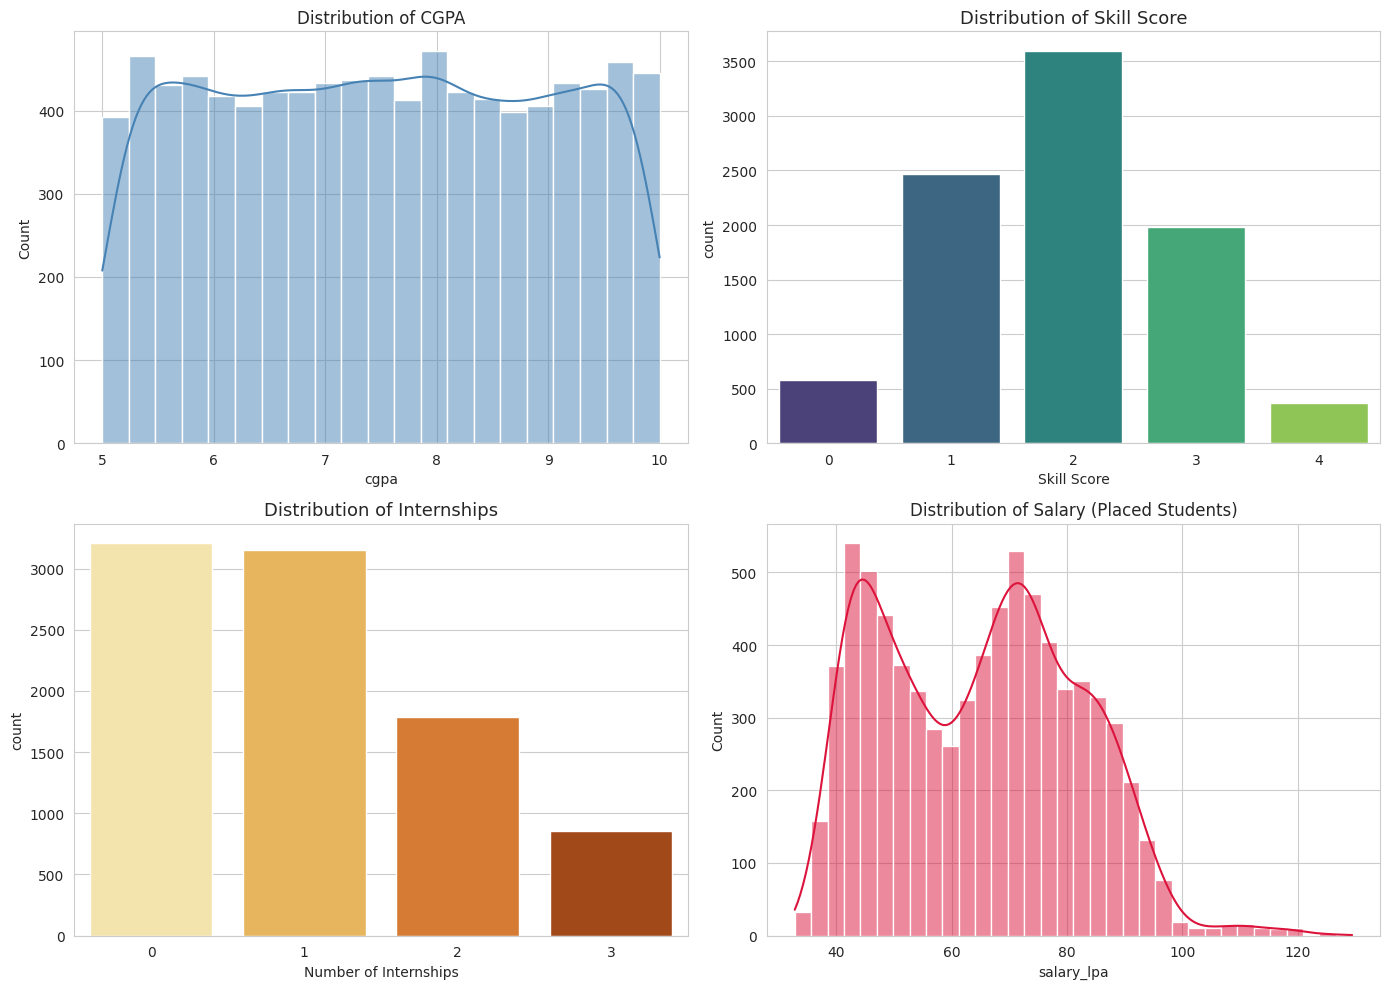

              cgpa  skill_score  internships   salary_lpa
count  9000.000000  9000.000000  9000.000000  9000.000000
mean      7.507213     1.898889     1.032000    55.409311
std       1.446496     0.953059     0.966191    27.673531
min       5.000000     0.000000     0.000000     0.000000
25%       6.257500     1.000000     0.000000    43.427500
50%       7.500000     2.000000     1.000000    60.100000
75%       8.750000     3.000000     2.000000    75.380000
max      10.000000     4.000000     3.000000   129.430000


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['cgpa'], kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribution of CGPA')

sns.countplot(x='skill_score', data=df, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Distribution of Skill Score', fontsize=13)
axes[0, 1].set_xlabel('Skill Score')

sns.countplot(x='internships', data=df, ax=axes[1, 0], palette='YlOrBr')
axes[1, 0].set_title('Distribution of Internships', fontsize=13)
axes[1, 0].set_xlabel('Number of Internships')

sns.histplot(df[df['placed'] == 1]['salary_lpa'], kde=True, ax=axes[1, 1], color='crimson')
axes[1, 1].set_title('Distribution of Salary (Placed Students)')

plt.tight_layout()
plt.show()

print(df[['cgpa', 'skill_score', 'internships', 'salary_lpa']].describe())

**1. CGPA Distribution**

CGPA shows a healthy spread. There is no extreme skewness which means there are students from weak to excellent academic backgrounds. This is likely one of the strongest predictors for both placement and salary.


**2. Skill Score Distribution**

The majority of students fall in the average to good technical skill range. This distribution suggests that technical skills are decent overall, but only a small percentage of students stand out with very high skill scores.

**3. Distribution of Internships**

Internship experience is highly skewed. Most students have either 0 or 1 internship. Having 2 or more internships is relatively rare and could be a strong differentiating factor for placement and higher salary.

**4. Distribution of Salary (Placed Students Only)**

The clear bimodal pattern is very interesting. It strongly suggests there are two different tiers of job offers:

* Lower tier (~40-60 LPA): Likely Mass recruiters, Startups, Mid-size companies
* Higher tier (~65-90+ LPA): MNCs and Top Tech companies

This indicates that company_type and job_role will be crucial features when predicting salary.

### Bivariate — Correlation Heatmap

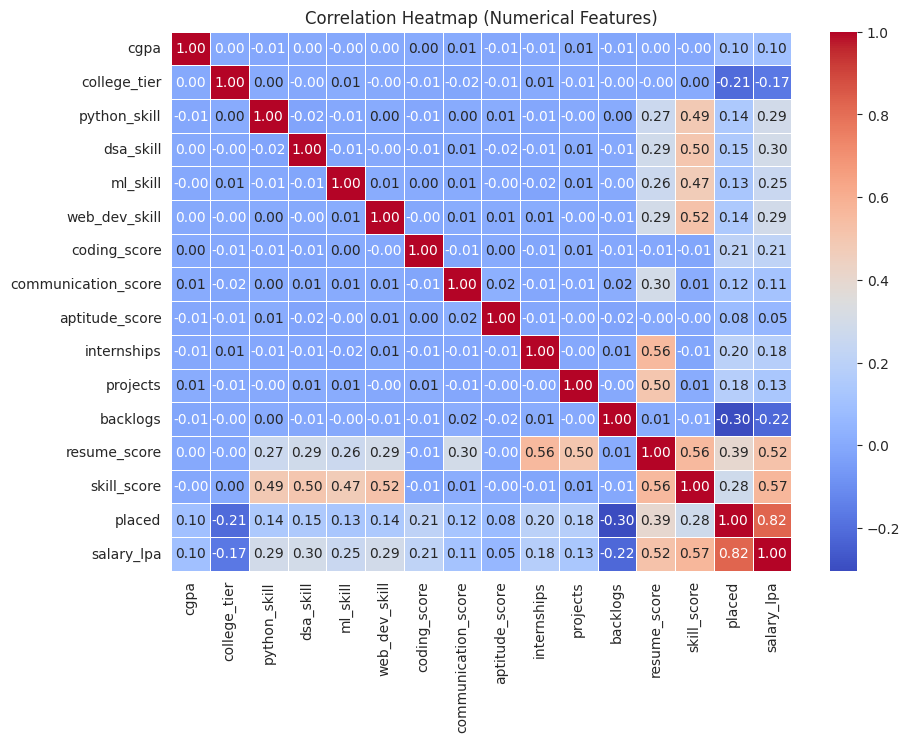

In [13]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

**For Placement (placed):**

The strongest feature is `resume_score`, though it is still only in the Weak category.
`backlogs` has one of the strongest negative impacts.
Most other features show Very Weak correlations. This suggests placement is influenced by a combination of many factors rather than one dominant variable.

**For Salary (salary_lpa):**

`skill_score` and `resume_score` show Moderate positive correlation. These are the most important features for predicting salary.
This makes sense because better skills and a stronger resume lead to better job offers.

**General Observations:**

CGPA has very weak correlation with both `placement` and `salary` indicating that skills and experience matter more than grades in this dataset.
Technical skills and resume quality play a bigger role than academic performance alone.
Negative factors (`backlogs`, `college_tier`) have clearer impact than many positive ones.

### Bivariate (vs Salary)

/tmp/ipykernel_30307/1249359938.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=placed_df, x='skill_score', y='salary_lpa', ax=axes[1],
/tmp/ipykernel_30307/1249359938.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=placed_df, x='internships', y='salary_lpa', ax=axes[2],


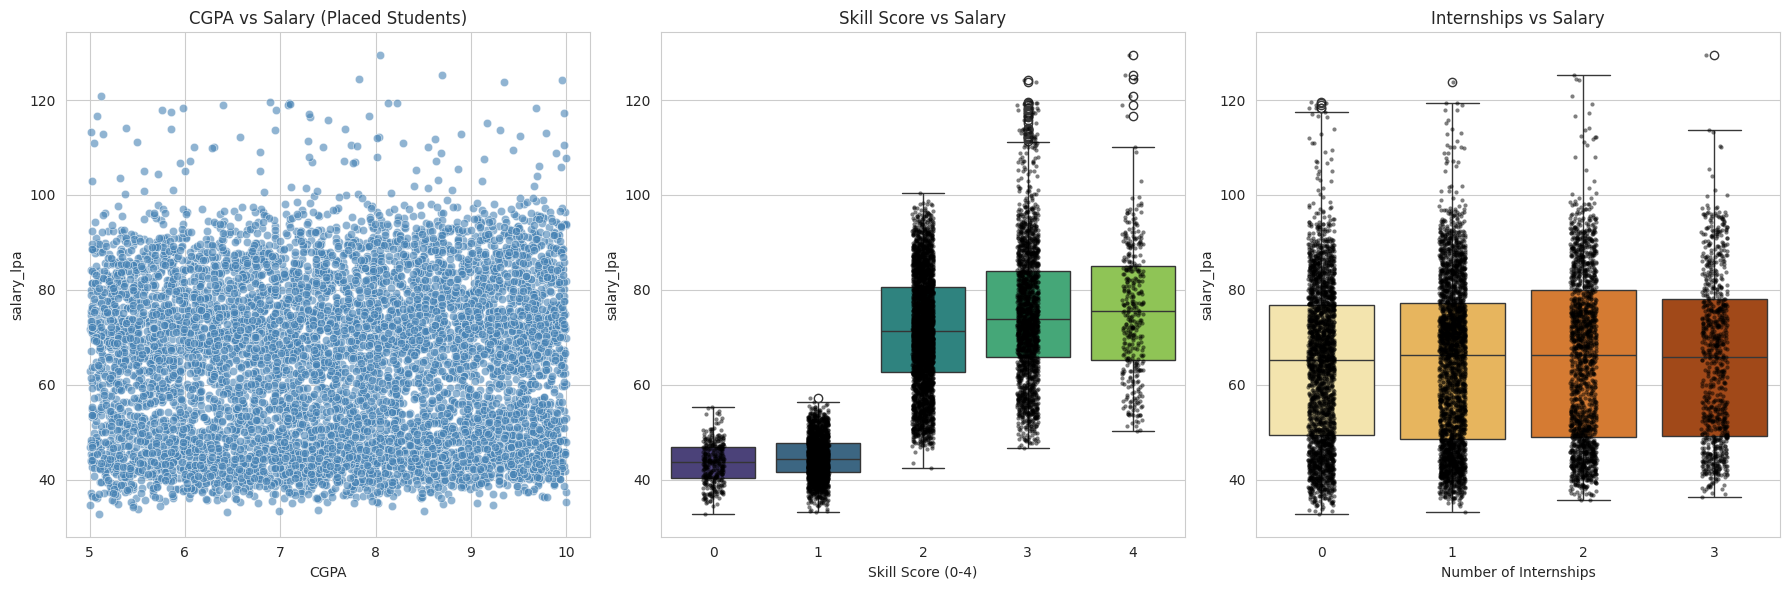

In [24]:
placed_df = df[df['placed'] == 1].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.scatterplot(data=placed_df, x='cgpa', y='salary_lpa', ax=axes[0],
                color='steelblue', alpha=0.6)
axes[0].set_title('CGPA vs Salary (Placed Students)')
axes[0].set_xlabel('CGPA')

sns.boxplot(data=placed_df, x='skill_score', y='salary_lpa', ax=axes[1],
            palette='viridis')
sns.stripplot(data=placed_df, x='skill_score', y='salary_lpa', ax=axes[1],
              color='black', alpha=0.5, jitter=True, size=3)
axes[1].set_title('Skill Score vs Salary')
axes[1].set_xlabel('Skill Score (0-4)')

sns.boxplot(data=placed_df, x='internships', y='salary_lpa', ax=axes[2],
            palette='YlOrBr')
sns.stripplot(data=placed_df, x='internships', y='salary_lpa', ax=axes[2],
              color='black', alpha=0.5, jitter=True, size=3)
axes[2].set_title('Internships vs Salary')
axes[2].set_xlabel('Number of Internships')

plt.tight_layout()
plt.show()

**1. CGPA vs Salary**

There is a weak positive trend: higher CGPA generally leads to slightly higher salaries.
However, the scatter is very wide. Students with CGPA 6.0 can get salaries ranging from ~35 LPA to 120+ LPA.
Even students with CGPA 9.0+ show huge variation in salary.


While CGPA helps, it is not a strong predictor of salary by itself. Many high-CGPA students still get average packages, and some average-CGPA students secure very high offers. This reinforces that skills and experience matter more than grades alone.

**2. Skill Score vs Salary**

As Skill Score increases from 0 to 4, both the median salary and the upper range increase significantly.
Students with Skill Score 0–1 mostly get salaries between 40–60 LPA.
Students with Skill Score 3–4 have much higher medians and many high outliers (100–120+ LPA).
The spread (box height) also increases with higher skill scores.


Skill Score is one of the strongest predictors of salary. Students who invest in building strong technical skills (Python, DSA, ML, Web Dev) have a clear advantage in securing higher-paying jobs.

**3. Internships vs Salary**

Students with more internships tend to get higher median salaries.
The biggest jump appears between 0 and 1 internship, and again between 1 and 2 internships.
Students with 2 or 3 internships show higher median salaries and more high-salary outliers.
However, even with 3 internships, there is still significant variation.

Internships provide a noticeable boost to salary, especially moving from 0 → 1 and 1 → 2. This suggests that practical experience is highly valued by recruiters and translates into better compensation.

### Placement Rate by Category

/tmp/ipykernel_30307/3279551903.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, ax=ax, palette='viridis')
/tmp/ipykernel_30307/3279551903.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, ax=ax, palette='viridis')
/tmp/ipykernel_30307/3279551903.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, ax=ax, palette='viridis')
/tmp/ipykernel_30307/3279551903.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed

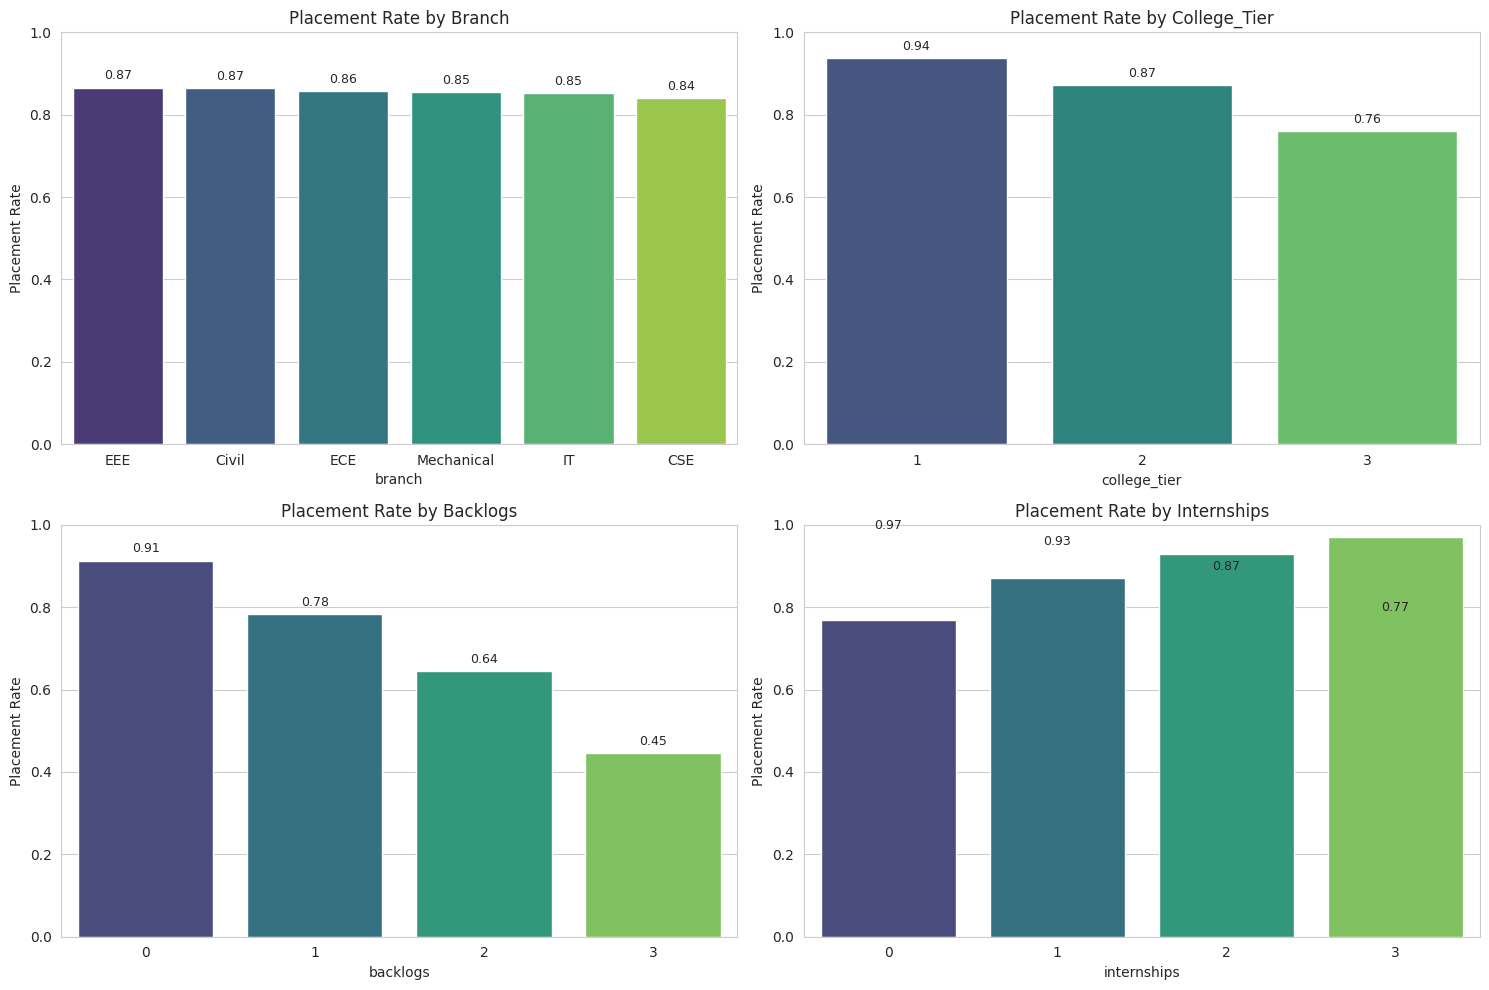

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, col in zip(axes.flatten(), ['branch', 'college_tier', 'backlogs', 'internships']):
    rate = df.groupby(col)['placed'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax, palette='viridis')
    ax.set_title(f'Placement Rate by {col.title()}')
    ax.set_ylabel('Placement Rate')
    ax.set_ylim(0, 1)
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**1. Placement Rate by Branch**

"Non-core" branches like Civil and Mechanical have very high placement rates. This suggests that skills, resume, and internships matter far more than the specific branch a student is from.

**2. Placement Rate by College Tier**

College tier has a very strong impact. Students from Tier 1 colleges have a 18% point advantage over Tier 3 students. Tier 3 students need to compensate significantly with skills and experience.

**3. Placement Rate by Backlogs**

This is one of the strongest negative factors. Each additional backlog causes a massive drop in placement probability. Students with 3 backlogs have less than 50% chance of getting placed. Avoiding backlogs should be a top priority.

**4. Placement Rate by Internships**

Having at least 1 internship gives a massive boost. Interestingly, 3 internships give the highest placement rate. This strongly supports the idea that practical experience is highly valued by recruiters.

### Salary Distribution (Placed Students Only)

/tmp/ipykernel_30307/3691276834.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=placed_df, x='college_tier', y='salary_lpa', ax=axes[1], palette='Blues')
/tmp/ipykernel_30307/3691276834.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=placed_df, x='branch', y='salary_lpa', ax=axes[2], palette='Set2')


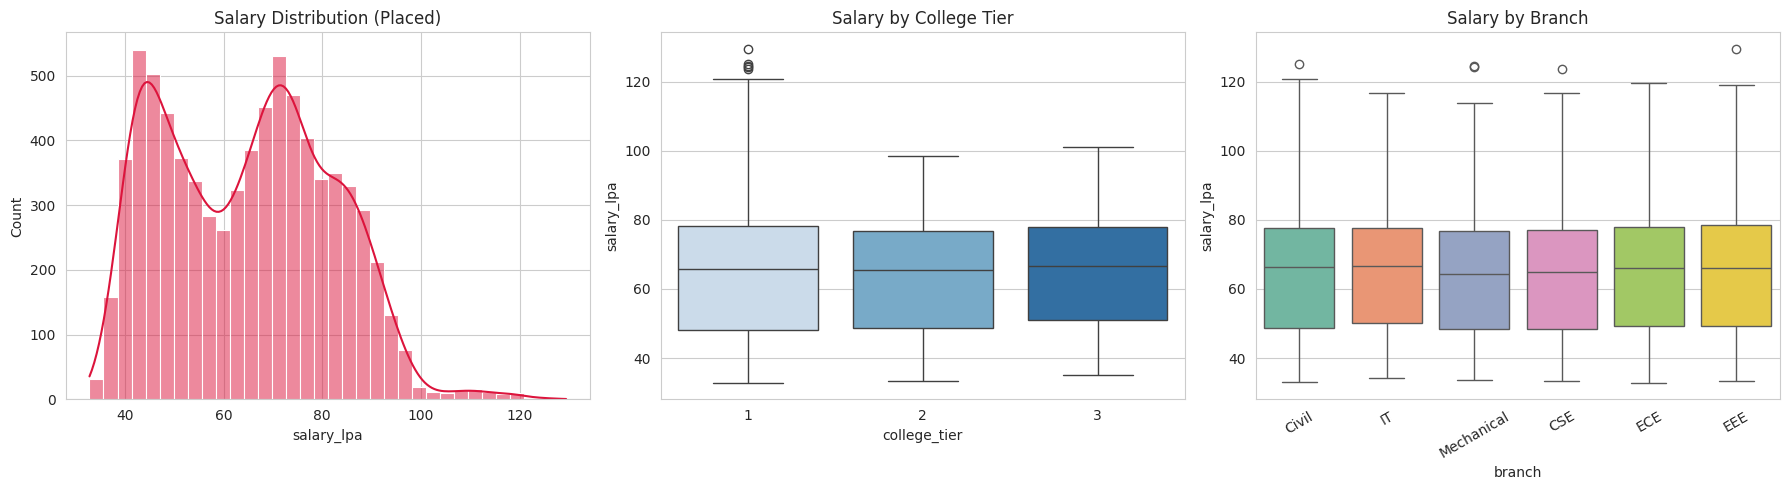

In [16]:
placed_df = df[df['placed'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(placed_df['salary_lpa'], kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Salary Distribution (Placed)')

sns.boxplot(data=placed_df, x='college_tier', y='salary_lpa', ax=axes[1], palette='Blues')
axes[1].set_title('Salary by College Tier')

sns.boxplot(data=placed_df, x='branch', y='salary_lpa', ax=axes[2], palette='Set2')
axes[2].set_title('Salary by Branch')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**1. Overall Salary Distribution (Placed Students)**

The bimodal distribution confirms that there are two different job market tiers:

* Lower tier (~40–60 LPA): Likely offers from Startups, Mid-size companies, or mass recruiters.
* Upper tier (~65–90+ LPA): Offers from MNCs and Top Tech companies.

This pattern suggests that salary is not uniformly distributed. Getting into the "upper tier" is a significant jump.

**2. Salary by College Tier (Boxplot)**

College tier has a clear impact on salary. Tier 1 students not only get placed more often but also secure higher-paying offers. Tier 3 students face a double disadvantage: lower placement rate and lower compensation when placed.

**3. Salary by Branch**

Unlike college tier, branch has minimal impact on salary. Whether a student is from CSE, Mechanical, Civil, or EEE, the salary distribution looks fairly consistent. This reinforces the earlier finding that skills, internships, and resume matter more than the specific branch.